In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Load the dataset with absolute path
df = pd.read_csv(r'c:\Users\Umar\OneDrive\Documents\DH-AI_internship\task 3\heart_disease_uci.csv')

# If you don't have the CSV yet, you can use this line to load a sample version:
# df = pd.read_csv('https://raw.githubusercontent.com/datasets/heart-disease-dataset/master/data/heart.csv')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64


C:\Users\Umar\AppData\Local\Temp\ipykernel_2388\833033331.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='viridis')


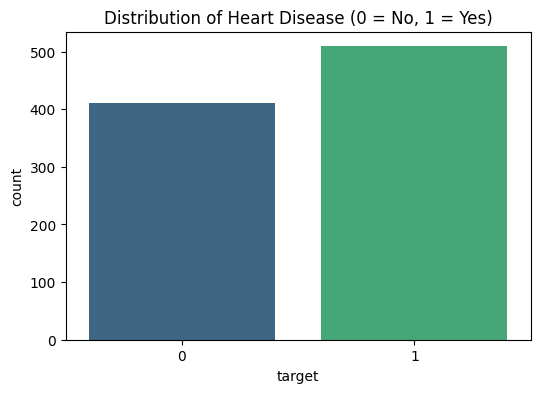

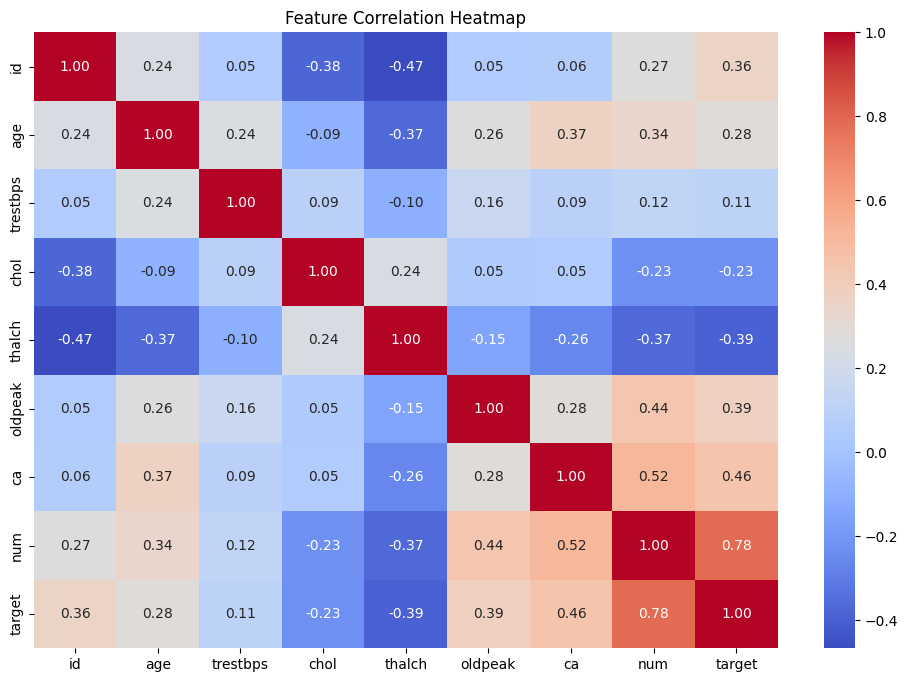

In [3]:
# 1. Check for missing values
print("Missing values:\n", df.isnull().sum())

# 2. Convert 'num' to binary target (0 = No disease, 1 = Disease present)
df['target'] = (df['num'] > 0).astype(int)

# 3. Visualize the Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='viridis')
plt.title("Distribution of Heart Disease (0 = No, 1 = Yes)")
plt.show()

# 4. Correlation Heatmap (numeric columns only)
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Define Features (X) and Target (y)
# Select only numeric columns and drop non-numeric and target columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
# Remove target and original num from features
X = df[numeric_cols].drop(['target', 'num', 'id'], axis=1)
y = df['target']

# Fill NaN values with column mean
X = X.fillna(X.mean())

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Classification Model Trained!")

Classification Model Trained!


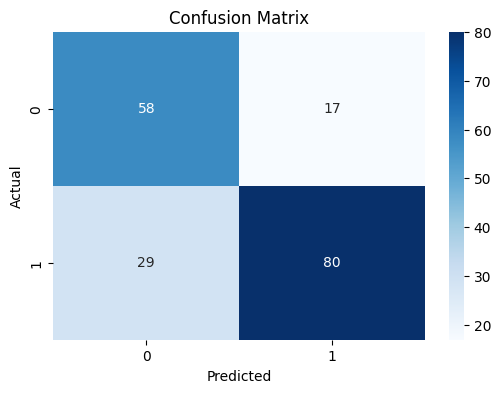


Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.77      0.72        75
           1       0.82      0.73      0.78       109

    accuracy                           0.75       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.76      0.75      0.75       184



In [8]:
predictions = model.predict(X_test)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 2. Classification Report
print("\nClassification Report:\n", classification_report(y_test, predictions))

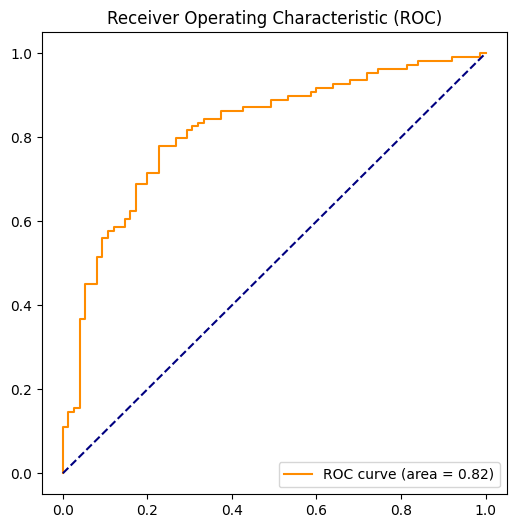

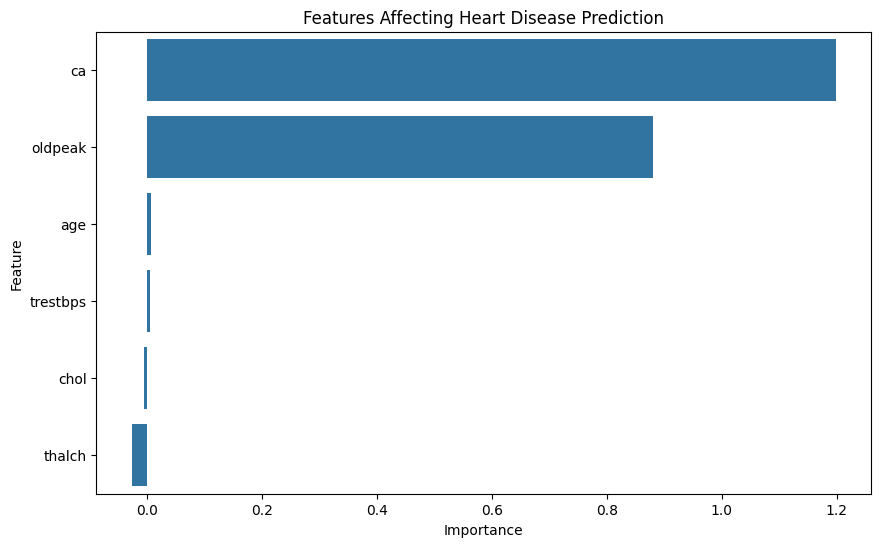

In [9]:
# 1. ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# 2. Feature Importance (Coefficients)
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Features Affecting Heart Disease Prediction')
plt.show()